In [ ]:
import pandas as pd
from transformers import AutoTokenizer

In [26]:
data_paths = ['data/nli/anli_v1.0/R2/dev.jsonl',
              'data/nli/anli_v1.0/R2/test.jsonl',
              'data/nli/anli_v1.0/R2/train.jsonl']

In [27]:
data = []
for path in data_paths:
    tmp_data = pd.read_json(path, lines=True)
    data.append(tmp_data)
    
data = pd.concat(data)


In [28]:
data['label'].value_counts()

label
n    21625
e    15116
c    10719
Name: count, dtype: int64

In [29]:
# exclude premises already used for test data

test_set = pd.read_json('new_module/data/logical-consistency/anli-r2-test_prompt_4.jsonl', lines=True)
test_set['premise'] = test_set['prompt'].apply(lambda x: x['text'])
print('Number of records in test set: ', test_set.shape[0])

Number of records in test set:  1000


In [33]:
print('Total number of records: ', data.shape[0])
print('Total number of unique premises: ', data['context'].nunique())
print('Number of unique premises to exclude: ', test_set['premise'].nunique())
print('Number of records with premises to exclude: ', data['context'].isin(test_set['premise']).sum())
print('Number of records to keep: ', data.loc[~data['context'].isin(test_set['premise'].tolist())].shape[0])
print('Number of entailment records to keep: ', data.loc[~data['context'].isin(test_set['premise'].tolist()) & (data['label'] == 'e')].shape[0])

Total number of records:  47460
Total number of unique premises:  2694
Number of unique premises to exclude:  881
Number of records with premises to exclude:  15731
Number of records to keep:  31729
Number of entailment records to keep:  10312


In [34]:
data = data.loc[(~data['context'].isin(test_set['premise'])) & 
                (data['label'] == 'e')].copy()

In [35]:
print(data.shape[0])

10312


In [ ]:


tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct')
data['hypothesis_ntokens'] = data['hypothesis'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=False)))

/home/hyeryung/.local/lib/python3.8/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


<Axes: >

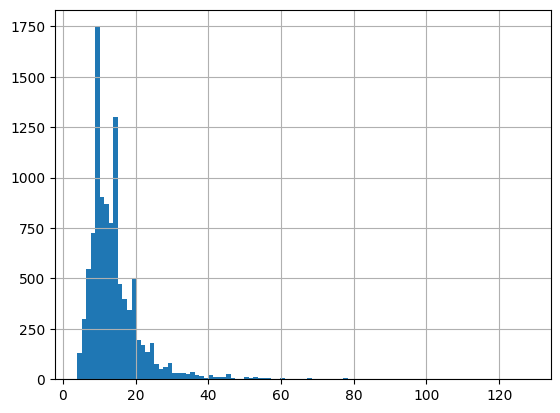

In [38]:
data['hypothesis_ntokens'].hist(bins=100)

In [43]:
data['hypothesis_ntokens'].describe()

count    10312.000000
mean        14.240981
std          8.042537
min          4.000000
25%         10.000000
50%         12.000000
75%         16.000000
max        128.000000
Name: hypothesis_ntokens, dtype: float64

In [44]:
from sklearn.model_selection import train_test_split


test_size = int(data.shape[0] * 0.05 // 100 * 100)

train, valid = train_test_split(data, test_size=test_size, random_state=42)
print(train.shape[0], validation.shape[0])


9812 500


In [45]:
import os
data_dir = 'new_module/data/logical-consistency/scope'
train.to_json(os.path.join(data_dir, 'train.jsonl'), orient='records', lines=True)
valid.to_json(os.path.join(data_dir, 'valid.jsonl'), orient='records', lines=True)
